# Garbage Classification using MLP from Scratch

This notebook implements a Multi-Layer Perceptron (MLP) neural network from scratch for classifying garbage images from the [Garbage Classification](https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification) dataset.

## 1. Import Required Libraries

We'll only use basic libraries like numpy for math operations, matplotlib for visualization, and standard libraries for data handling. No PyTorch or other deep learning frameworks will be used.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import seaborn as sns
import random
import zipfile
import time
import sys
import kagglehub

# For reproducibility
np.random.seed(42)
random.seed(42)

In [22]:

DATA_DIR = "./Garbage classification"

print(f"Found data directory: {DATA_DIR}")

print("Directory structure:")
for item in os.listdir(DATA_DIR):
    path = os.path.join(DATA_DIR, item)
    if os.path.isdir(path):
        print(f"  - {item}/ (directory with {len(os.listdir(path))} items)")
    else:
        print(f"  - {item} (file)")

garbage_dir = os.path.join(DATA_DIR, "Garbage classification")

if os.path.exists(garbage_dir):
    DATA_DIR = garbage_dir
    print(f"Using actual garbage classification directory: {DATA_DIR}")
    categories = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    print(f"Found {len(categories)} categories: {categories}")


Found data directory: ./Garbage classification
Directory structure:
  - cardboard/ (directory with 403 items)
  - glass/ (directory with 501 items)
  - metal/ (directory with 410 items)
  - paper/ (directory with 594 items)
  - plastic/ (directory with 482 items)
  - trash/ (directory with 137 items)


## 3. Data Preprocessing

We'll load the images, resize them to a manageable size, convert them to grayscale to reduce dimensionality, and flatten them for our MLP input.

In [35]:
def load_and_preprocess_data(data_dir, img_size=(128, 128)):
    X = []
    y = []
    
    categories = [d for d in os.listdir(data_dir) 
                  if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')]
    categories.sort()  
    for category_idx, category in enumerate(categories):
        category_path = os.path.join(data_dir, category)
        
        if not os.path.isdir(category_path):
            continue
            
        print(f"Processing category: {category} ({category_idx})")
        image_files = [f for f in os.listdir(category_path) 
                      if f.lower().endswith(('.jpg'))]            
        for img_file in tqdm(image_files[:500]): 
            img_path = os.path.join(category_path, img_file)
            
            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: Could not read {img_path}")
                continue
            img = cv2.resize(img, img_size)
            flattened_img = img.flatten() / 255.0  
            X.append(flattened_img)
            y.append(category_idx)
                
        
    return np.array(X), np.array(y), categories

X, y, class_names = load_and_preprocess_data(DATA_DIR)

print(f"Data shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of classes: {len(class_names)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")


Processing category: cardboard (0)


100%|██████████| 403/403 [00:00<00:00, 1660.67it/s]


Processing category: glass (1)


100%|██████████| 500/500 [00:00<00:00, 1798.14it/s]


Processing category: metal (2)


...

Processing category: plastic (4)


100%|██████████| 482/482 [00:00<00:00, 1653.98it/s]


Processing category: trash (5)


100%|██████████| 137/137 [00:00<00:00, 1556.73it/s]



Data shape: (2432, 49152)
Labels shape: (2432,)
Number of classes: 6
Training data: (1945, 49152)
Testing data: (487, 49152)


In [49]:
class MLP:
    def __init__(self, input_size, hidden_sizes, output_size):
        self.layers = []
        self.biases = []
        self.activations = []

        layer_sizes = [input_size] + hidden_sizes + [output_size]

        for i in range(len(layer_sizes) - 1):
            weight = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * np.sqrt(2. / layer_sizes[i])
            bias = np.zeros((1, layer_sizes[i + 1]))
            self.layers.append(weight)
            self.biases.append(bias)

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        self.activations = [X]
        a = X
        for i in range(len(self.layers) - 1):
            z = a @ self.layers[i] + self.biases[i]
            a = self.relu(z)
            self.activations.append(a)
        z = a @ self.layers[-1] + self.biases[-1]
        out = self.softmax(z)
        self.activations.append(out)
        return out

    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        log_probs = -np.log(y_pred[range(m), y_true] + 1e-9)
        return np.sum(log_probs) / m

    def compute_accuracy(self, y_pred, y_true):
        predictions = np.argmax(y_pred, axis=1)
        return np.mean(predictions == y_true)

    def backward(self, y_pred, y_true):
        grads_w = []
        grads_b = []

        m = y_true.shape[0]
        y_true_one_hot = np.zeros_like(y_pred)
        y_true_one_hot[np.arange(m), y_true] = 1

        delta = (y_pred - y_true_one_hot) / m

        for i in reversed(range(len(self.layers))):
            a_prev = self.activations[i]
            dw = a_prev.T @ delta
            db = np.sum(delta, axis=0, keepdims=True)
            grads_w.insert(0, dw)
            grads_b.insert(0, db)

            if i != 0:
                da_prev = delta @ self.layers[i].T
                delta = da_prev * self.relu_derivative(a_prev)

        return grads_w, grads_b

    def update_params(self, grads_w, grads_b, lr):
        for i in range(len(self.layers)):
            self.layers[i] -= lr * grads_w[i]
            self.biases[i] -= lr * grads_b[i]

    def train(self, X_train, y_train, X_val, y_val, epochs=10, learning_rate=0.001):
        history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
        for epoch in range(epochs):
            y_pred_train = self.forward(X_train)
            loss = self.compute_loss(y_pred_train, y_train)
            acc = self.compute_accuracy(y_pred_train, y_train)

            grads_w, grads_b = self.backward(y_pred_train, y_train)
            self.update_params(grads_w, grads_b, learning_rate)

            y_pred_val = self.forward(X_val)
            val_loss = self.compute_loss(y_pred_val, y_val)
            val_acc = self.compute_accuracy(y_pred_val, y_val)

            history["loss"].append(loss)
            history["val_loss"].append(val_loss)
            history["accuracy"].append(acc)
            history["val_accuracy"].append(val_acc)

            print(f"Epoch {epoch+1:02}/{epochs} "
                  f"| Loss: {loss:.4f} | Acc: {acc:.4f} "
                  f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        return history

    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)


Let's visualize some sample images from our dataset to get a feel for what we're working with.

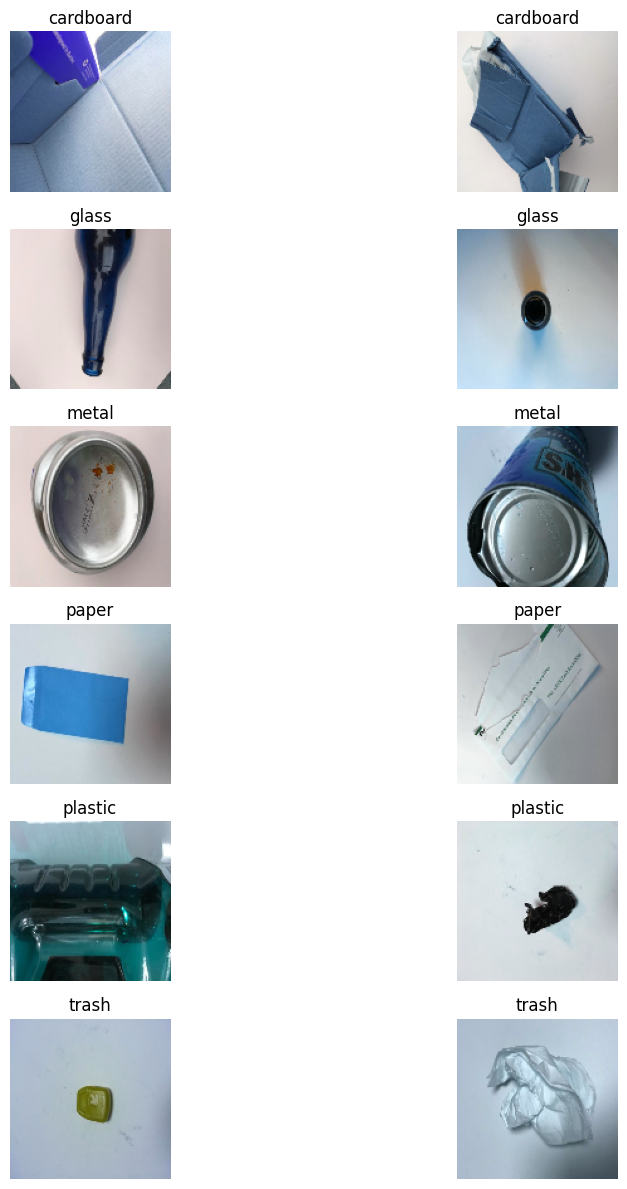

In [47]:
def display_samples(X, y, class_names, img_size=(128, 128), samples_per_class=2):
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(12, 12))
    
    for class_idx, class_name in enumerate(class_names):
        class_indices = np.where(y == class_idx)[0]
        
        if len(class_indices) >= samples_per_class:
            sample_indices = np.random.choice(class_indices, samples_per_class, replace=False)
            
            for i, sample_idx in enumerate(sample_indices):
                img = X[sample_idx].reshape(img_size[0], img_size[1], 3)  
                axes[class_idx, i].imshow(img) 
                axes[class_idx, i].set_title(class_name)
                axes[class_idx, i].axis('off')
    
    plt.tight_layout()
    plt.show()

if 'X' in locals() and 'y' in locals() and 'class_names' in locals():
    display_samples(X, y, class_names)

Now let's train the MLP on the garbage classification data.

In [50]:
if 'X_train' in locals() and 'X_test' in locals():
    # split into training and validation
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
    
    input_size = X_train.shape[1] 
    hidden_sizes = [2056,1028,1028, 512,256,128]  
    output_size = len(class_names) 
    
    mlp = MLP(input_size, hidden_sizes, output_size)
    
    print("Training MLP...")
    history = mlp.train(
        X_train, y_train,
        X_val, y_val,
        epochs=30,
        learning_rate=0.001
    )
    print("Training completed!")

Training MLP...
Epoch 01/30 | Loss: 1.8961 | Acc: 0.1651 | Val Loss: 1.7966 | Val Acc: 0.2437
Epoch 01/30 | Loss: 1.8961 | Acc: 0.1651 | Val Loss: 1.7966 | Val Acc: 0.2437
Epoch 02/30 | Loss: 1.7658 | Acc: 0.2453 | Val Loss: 1.7525 | Val Acc: 0.2375
Epoch 02/30 | Loss: 1.7658 | Acc: 0.2453 | Val Loss: 1.7525 | Val Acc: 0.2375
Epoch 03/30 | Loss: 1.7002 | Acc: 0.2531 | Val Loss: 1.7218 | Val Acc: 0.2562
Epoch 03/30 | Loss: 1.7002 | Acc: 0.2531 | Val Loss: 1.7218 | Val Acc: 0.2562
Epoch 04/30 | Loss: 1.6730 | Acc: 0.2736 | Val Loss: 1.7550 | Val Acc: 0.2500
Epoch 04/30 | Loss: 1.6730 | Acc: 0.2736 | Val Loss: 1.7550 | Val Acc: 0.2500
Epoch 05/30 | Loss: 1.6722 | Acc: 0.2956 | Val Loss: 1.7578 | Val Acc: 0.2313
Epoch 05/30 | Loss: 1.6722 | Acc: 0.2956 | Val Loss: 1.7578 | Val Acc: 0.2313
Epoch 06/30 | Loss: 1.7183 | Acc: 0.2107 | Val Loss: 1.9552 | Val Acc: 0.2062
Epoch 06/30 | Loss: 1.7183 | Acc: 0.2107 | Val Loss: 1.9552 | Val Acc: 0.2062
Epoch 07/30 | Loss: 1.8443 | Acc: 0.2280 | Val L

<Figure size 1000x800 with 0 Axes>

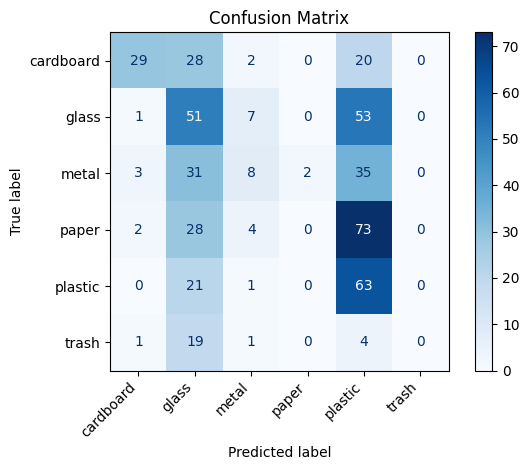

Test Accuracy: 0.3101
cardboard accuracy: 0.3671
glass accuracy: 0.4554
metal accuracy: 0.1013
paper accuracy: 0.0000
plastic accuracy: 0.7412
trash accuracy: 0.0000


In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    accuracy = np.sum(np.diag(cm)) / np.sum(cm)
    print(f"Test Accuracy: {accuracy:.4f}")
    
    class_accuracy = np.diag(cm) / np.sum(cm, axis=1)
    for i, class_name in enumerate(class_names):
        print(f"{class_name} accuracy: {class_accuracy[i]:.4f}")

plot_confusion_matrix(mlp, X_test, y_test, class_names)
